#พิทวัส พิรักษา
#6609612152

#Data Acquisition (Secondary Data Collection)

In [ ]:
# Load libraries
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

In [ ]:
#
df = pd.read_csv('https://raw.githubusercontent.com/qpitawat/CS372_MiniProject/refs/heads/main/Spotify_Tracks_Dataset.csv')

In [ ]:
#
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
# แสดงชื่อทุกคอลัมน์ในชุดข้อมูล
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [ ]:
# แสดงประเภทข้อมูลและข้อมูลทั่วไปของแต่ละคอลัมน์
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [ ]:
df.shape

(114000, 21)

# Data Preparation

In [ ]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
# ลบคอลัมน์ที่ไม่จำเป็นสำหรับการฝึกแบบจำลอง เพราะเป็นข้อมูลประเภท String ที่ยากต่อการจัดการ
df.drop(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name'], axis=1, inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(7093)

In [ ]:
df[df.duplicated()]

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
28,0,131760,False,0.620,0.309,5,-9.209,1,0.0495,0.788000,0.000000,0.1460,0.6640,145.363,4,acoustic
29,0,131760,False,0.620,0.309,5,-9.209,1,0.0495,0.788000,0.000000,0.1460,0.6640,145.363,4,acoustic
30,0,131760,False,0.620,0.309,5,-9.209,1,0.0495,0.788000,0.000000,0.1460,0.6640,145.363,4,acoustic
31,0,131760,False,0.620,0.309,5,-9.209,1,0.0495,0.788000,0.000000,0.1460,0.6640,145.363,4,acoustic
34,0,259558,False,0.296,0.206,0,-11.799,1,0.0412,0.782000,0.000225,0.0959,0.2020,165.400,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113041,2,205738,False,0.675,0.375,6,-8.985,1,0.0452,0.542000,0.000003,0.0951,0.1870,134.023,4,world-music
113345,34,265373,False,0.487,0.895,11,-5.061,1,0.0413,0.000183,0.000000,0.3590,0.3840,105.021,4,world-music
113644,43,274533,False,0.454,0.635,10,-8.286,1,0.0331,0.010300,0.000000,0.2330,0.0931,148.169,4,world-music
113786,43,235599,False,0.406,0.121,5,-11.650,1,0.0373,0.806000,0.000000,0.1150,0.3870,118.071,4,world-music


In [ ]:
df_dropdup = df.drop_duplicates()
df_dropdup

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [ ]:
df_dropdup.shape

(106907, 16)

In [ ]:
df_dropdup.isnull().sum()

,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0
loudness,0
mode,0
speechiness,0
acousticness,0


In [ ]:
# แสดงประเภทเพลงที่ไม่ซ้ำกันทั้งหมดในชุดข้อมูล
df_dropdup['track_genre'].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

In [ ]:
# นับจำนวน track genre ว่าแต่ละอันมีเท่าไหร่
df_dropdup['track_genre'].value_counts()

,count
track_genre,
samba,1000
mandopop,1000
j-idol,999
mpb,999
tango,999
...,...
rock,717
country,698
dance,692


In [ ]:
# กำหนดประเภทเพลง 10 ประเภทที่ต้องการ
target_genres = [
    'pop', 'rock', 'hip-hop', 'classical', 'jazz',
    'electronic', 'metal', 'reggae', 'country', 'blues'
]

In [ ]:
df_filtered = df_dropdup[df_dropdup['track_genre'].isin(target_genres)].copy()

In [ ]:
df_filtered['track_genre'].value_counts()

,count
track_genre,
electronic,988
metal,919
pop,874
classical,864
hip-hop,827
reggae,803
blues,796
rock,717
country,698


<Axes: xlabel='track_genre', ylabel='count'>

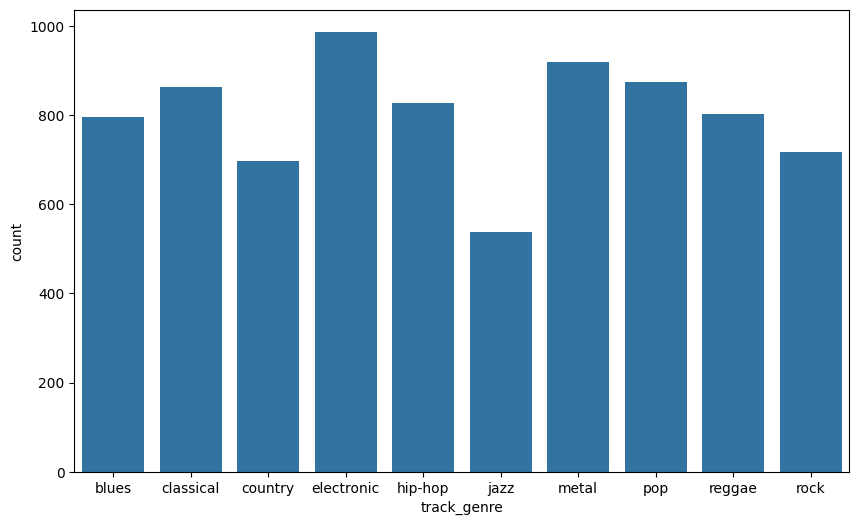

In [ ]:
# แสดงกราฟแท่ง (bar chart) เพื่อแสดงจำนวนเพลงในแต่ละประเภท
# ช่วยให้เห็นการกระจายของข้อมูลสำหรับแต่ละคลาส
plt.figure(figsize=(10, 6))
sns.countplot(data=df_filtered, x='track_genre')

In [ ]:
df_filtered.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
8000,77,230613,False,0.509,0.448,4,-7.552,0,0.0357,0.00713,0.013700,0.2440,0.221,156.909,3,blues
8001,79,208760,False,0.636,0.676,2,-3.442,1,0.0263,0.08070,0.000000,0.0831,0.273,113.980,4,blues
8002,76,180690,False,0.573,0.539,2,-6.091,0,0.0322,0.01620,0.000012,0.1050,0.390,75.012,4,blues
8003,84,232106,False,0.743,0.446,4,-7.807,0,0.0683,0.00390,0.118000,0.3370,0.278,123.596,4,blues
8004,76,225026,False,0.572,0.214,7,-15.625,1,0.0293,0.64900,0.129000,0.1250,0.485,95.542,4,blues


In [ ]:
df_filtered.shape

(8024, 16)

In [ ]:
# แปลงข้อมูลประเภท String (explicit และ track_genre) เป็นตัวเลขโดยใช้ Label Encoding
# เพื่อให้โมเดลสามารถประมวลผลได้
le = LabelEncoder()
df_filtered['explicit'] = le.fit_transform(df_filtered['explicit'])
df_filtered['track_genre'] = le.fit_transform(df_filtered['track_genre'])

In [ ]:
df_filtered.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
8000,77,230613,0,0.509,0.448,4,-7.552,0,0.0357,0.00713,0.013700,0.2440,0.221,156.909,3,0
8001,79,208760,0,0.636,0.676,2,-3.442,1,0.0263,0.08070,0.000000,0.0831,0.273,113.980,4,0
8002,76,180690,0,0.573,0.539,2,-6.091,0,0.0322,0.01620,0.000012,0.1050,0.390,75.012,4,0
8003,84,232106,0,0.743,0.446,4,-7.807,0,0.0683,0.00390,0.118000,0.3370,0.278,123.596,4,0
8004,76,225026,0,0.572,0.214,7,-15.625,1,0.0293,0.64900,0.129000,0.1250,0.485,95.542,4,0


In [ ]:
X = df_filtered.drop('track_genre', axis=1)
y = df_filtered['track_genre']

In [ ]:
# ปรับขนาดข้อมูล (Normalization) โดยใช้ StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,1.361871,0.032511,-0.318261,-0.433111,-0.651235,-0.381102,0.151059,-1.276360,-0.540764,-0.932442,-0.382938,0.423806,-1.132864,1.198504,-2.191282
1,1.427911,-0.183471,-0.318261,0.316326,0.255668,-0.946291,0.877468,0.783478,-0.666775,-0.715455,-0.432174,-0.683963,-0.918667,-0.205852,0.231933
2,1.328852,-0.460898,-0.318261,-0.055442,-0.289270,-0.946291,0.409279,-1.276360,-0.587683,-0.905691,-0.432132,-0.533186,-0.436726,-1.480630,0.231933
3,1.593009,0.047267,-0.318261,0.947740,-0.659191,-0.381102,0.105990,-1.276360,-0.103747,-0.941968,-0.008095,1.064096,-0.898072,0.108721,0.231933
4,1.328852,-0.022708,-0.318261,-0.061343,-1.582005,0.466683,-1.275778,0.783478,-0.626558,0.960689,0.031438,-0.395489,-0.045405,-0.809023,0.231933


In [ ]:
# แบ่งข้อมูลออกเป็น training set (80%) และ test set (20%)
# ใช้ stratify=y เพื่อให้อัตราส่วนของแต่ละคลาสเหมือนกันในทั้งสองชุด
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

#kNN

In [ ]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [ ]:
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=10, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [ ]:
print(f"Best Parameters: {knn_grid.best_params_}")
print(f"Best 10-fold CV Accuracy: {knn_grid.best_score_:.4f}")

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best 10-fold CV Accuracy: 0.4962


In [ ]:
knn = knn_grid.best_estimator_

class_names = le.classes_

y_pred = knn.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {test_accuracy:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=class_names))

knn_cm = confusion_matrix(y_test, y_pred)

Accuracy: 0.5003

Classification Report (Test Set):
              precision    recall  f1-score   support

       blues       0.31      0.21      0.25       159
   classical       0.90      0.82      0.86       173
     country       0.41      0.46      0.43       140
  electronic       0.60      0.56      0.58       198
     hip-hop       0.41      0.48      0.44       165
        jazz       0.39      0.38      0.39       107
       metal       0.57      0.66      0.61       184
         pop       0.37      0.41      0.39       175
      reggae       0.56      0.54      0.55       161
        rock       0.39      0.36      0.37       143

    accuracy                           0.50      1605
   macro avg       0.49      0.49      0.49      1605
weighted avg       0.50      0.50      0.50      1605



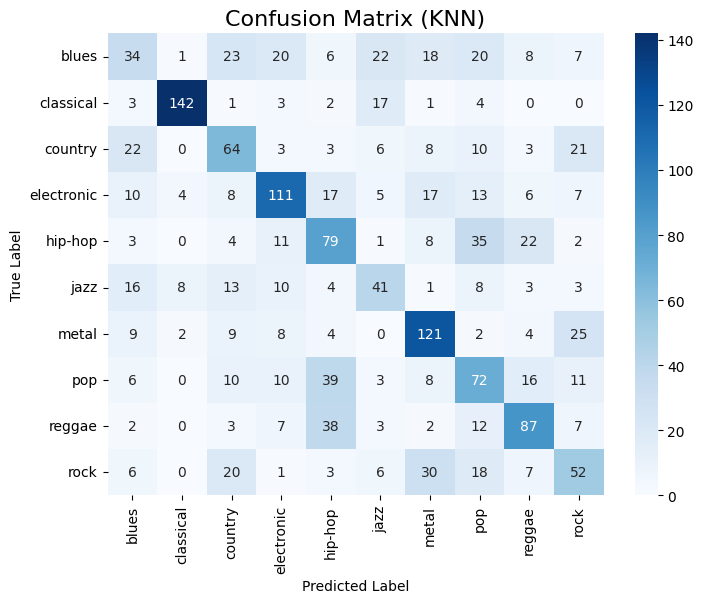

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (KNN)', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#XGboost

In [ ]:
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_grid = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
                        xgb_params, cv=10, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:56:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrai...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100]},
             scoring='accuracy')

In [ ]:
print(f"Best Parameters: {xgb_grid.best_params_}")
print(f"Best 10-fold CV Accuracy: {xgb_grid.best_score_:.4f}")

Best Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
Best 10-fold CV Accuracy: 0.6024


In [ ]:
xgb = xgb_grid.best_estimator_

class_names = le.classes_

y_pred = xgb.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {test_accuracy:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=class_names))

xgb_cm = confusion_matrix(y_test, y_pred)

Accuracy: 0.5944

Classification Report (Test Set):
              precision    recall  f1-score   support

       blues       0.39      0.40      0.39       159
   classical       0.88      0.86      0.87       173
     country       0.52      0.44      0.47       140
  electronic       0.69      0.76      0.72       198
     hip-hop       0.56      0.61      0.58       165
        jazz       0.47      0.48      0.47       107
       metal       0.69      0.72      0.71       184
         pop       0.52      0.56      0.54       175
      reggae       0.69      0.60      0.64       161
        rock       0.40      0.37      0.38       143

    accuracy                           0.59      1605
   macro avg       0.58      0.58      0.58      1605
weighted avg       0.59      0.59      0.59      1605



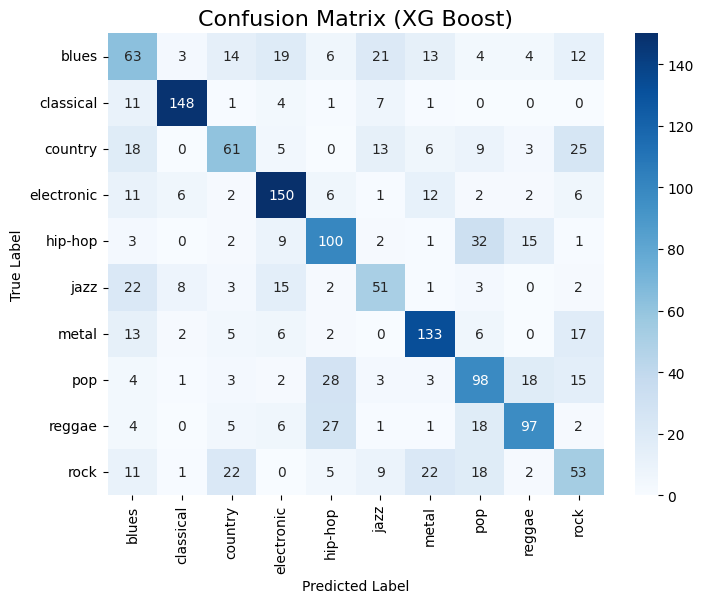

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (XG Boost)', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Neural Network

In [ ]:
mlp_params = {
    'hidden_layer_sizes': [(32,), (64,), (128,)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'batch_size': [64, 128, 256]
}

In [ ]:

mlp_grid = GridSearchCV(MLPClassifier(random_state=42), mlp_params, cv=10, scoring='accuracy', n_jobs=-1)
mlp_grid.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


GridSearchCV(cv=10, estimator=MLPClassifier(random_state=42), n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'alpha': [0.0001, 0.001, 0.01],
                         'batch_size': [64, 128, 256],
                         'hidden_layer_sizes': [(32,), (64,), (128,)]},
             scoring='accuracy')

In [ ]:
print(f"Best Parameters: {mlp_grid.best_params_}")
print(f"Best 10-fold CV Accuracy: {mlp_grid.best_score_:.4f}")

Best Parameters: {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 128, 'hidden_layer_sizes': (128,)}
Best 10-fold CV Accuracy: 0.5565


In [ ]:
nn = mlp_grid.best_estimator_

class_names = le.classes_

y_pred = nn.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {test_accuracy:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=class_names))

nn_cm = confusion_matrix(y_test, y_pred)

Accuracy: 0.5502

Classification Report (Test Set):
              precision    recall  f1-score   support

       blues       0.41      0.32      0.36       159
   classical       0.90      0.87      0.88       173
     country       0.45      0.39      0.41       140
  electronic       0.63      0.67      0.65       198
     hip-hop       0.52      0.59      0.55       165
        jazz       0.43      0.50      0.46       107
       metal       0.66      0.70      0.68       184
         pop       0.45      0.42      0.43       175
      reggae       0.56      0.56      0.56       161
        rock       0.35      0.37      0.36       143

    accuracy                           0.55      1605
   macro avg       0.54      0.54      0.53      1605
weighted avg       0.55      0.55      0.55      1605



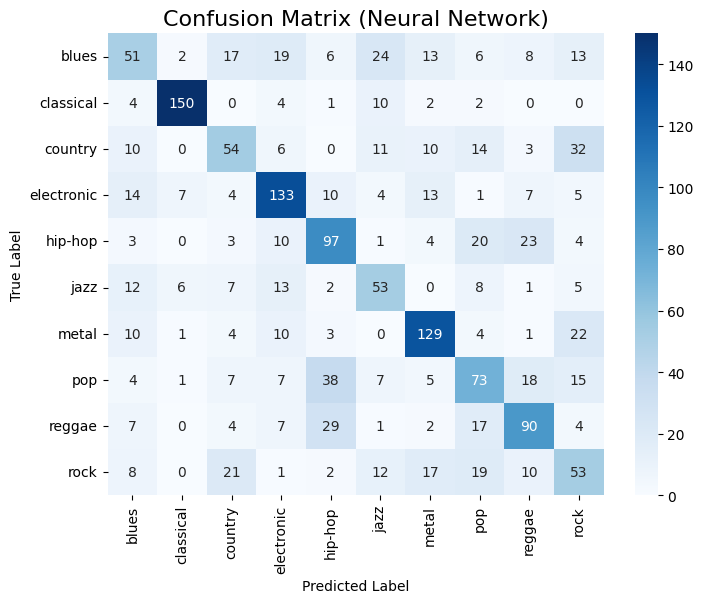

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(nn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Neural Network)', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

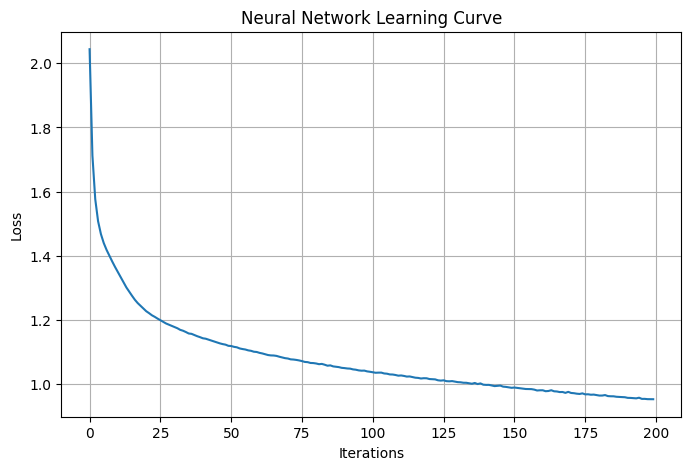

In [ ]:
# แสดง Learning Curve ของแบบจำลอง Neural Network
# กราฟนี้แสดงว่า Loss ลดลงอย่างไรตามจำนวน iterations
plt.figure(figsize=(8, 5))
plt.plot(nn.loss_curve_)
plt.title('Neural Network Learning Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

#Model Comparision

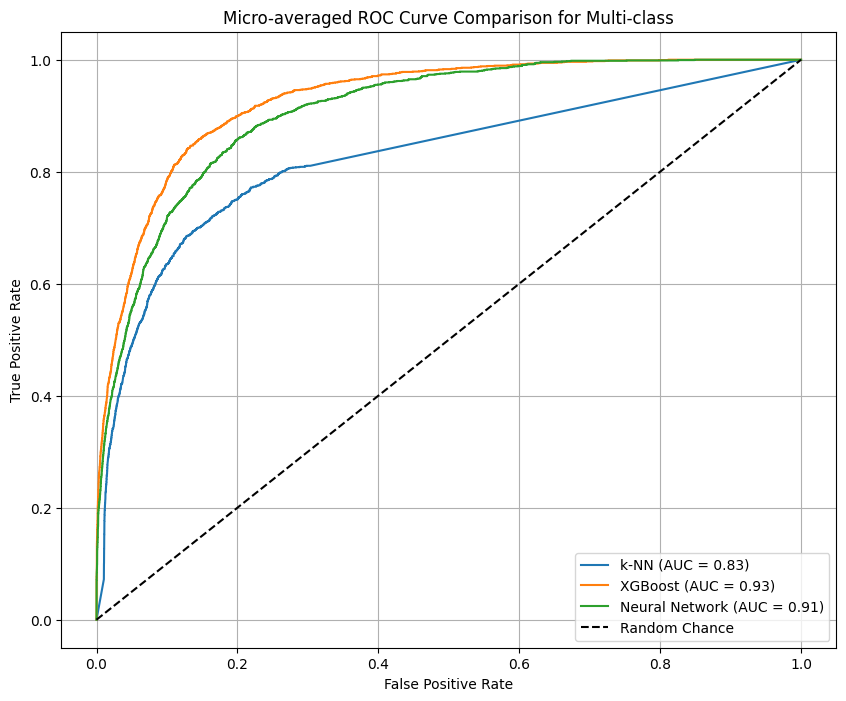

In [ ]:
# เปรียบเทียบประสิทธิภาพของทั้ง 3 แบบจำลอง โดยใช้ ROC Curve และ AUC Score
y_prob_knn = knn.predict_proba(X_test)
y_prob_xgb = xgb.predict_proba(X_test)
y_prob_nn = nn.predict_proba(X_test)

y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))

fpr_knn, tpr_knn, _ = roc_curve(y_test_binarized.ravel(), y_prob_knn.ravel())
auc_knn = roc_auc_score(y_test_binarized, y_prob_knn, multi_class='ovr', average='micro')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test_binarized.ravel(), y_prob_xgb.ravel())
auc_xgb = roc_auc_score(y_test_binarized, y_prob_xgb, multi_class='ovr', average='micro')

fpr_nn, tpr_nn, _ = roc_curve(y_test_binarized.ravel(), y_prob_nn.ravel())
auc_nn = roc_auc_score(y_test_binarized, y_prob_nn, multi_class='ovr', average='micro')

plt.figure(figsize=(10, 8))
plt.plot(fpr_knn, tpr_knn, label=f'k-NN (AUC = {auc_knn:.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-averaged ROC Curve Comparison for Multi-class')
plt.legend(loc='lower right')
plt.grid()
plt.show()